
# 05 — N=8 Kuramoto benchmark with measurement noise: relative-polynomial vs candidate libraries

This notebook tests the same planted \(N=8\) temporal Kuramoto system through two different interaction-library choices while keeping the upstream data, temporal segmentation, stage-local polynomial smoothing, noise-calibrated uncertainty floor, Step-2 reconstruction, and Step-3 physical hypothesis fixed.

The common pipeline is

\[
x(t)
\longrightarrow
\tau_{1:K-1}
\longrightarrow
\text{common midpoint observations}
\longrightarrow
\begin{cases}
\Psi_{\rm poly} \rightarrow \mathcal B_{\varepsilon}^{\rm poly},\\[1mm]
\Psi_{\rm cand} \rightarrow \mathcal B_{\varepsilon}^{\rm cand},
\end{cases}
\longrightarrow
\text{same }H_{\rm FD}\text{ Step-3 API}.
\]

The two libraries answer different inference questions:

- **relative polynomial**: reconstruct the interaction law in a generic basis
  \[
  z,z^2,\ldots,z^{11},\qquad z=(x_j-x_i)/s;
  \]
- **candidate**: select among predeclared physical mechanisms
  \[
  x_j-x_i,\quad \sin(x_j-x_i),\quad \tanh(x_j-x_i),\quad (x_j-x_i)^3.
  \]

Step 2 returns the same `EdgeSpaceFieldFamily` object type in both cases. Step 3 is called through the same fixed-dynamics physical-compression API; only the internal expression-search strategy and the interpretation of \(\Theta\) differ.

The known measurement-noise standard deviation is an experimental calibration input. Planted topology, weights and the sine law are used for generator/validation diagnostics, never to tune epsilon or initialize the inference. Restart the kernel and run all cells after updating local modules.


In [1]:

# ============================================================
# Cell 1 — imports and local-code discovery
# ============================================================
from pathlib import Path
from itertools import combinations
import sys
import time
import math
import importlib

import numpy as np
import matplotlib.pyplot as plt

HERE = Path.cwd()
CODE_DIR = None

for candidate in (
    HERE,
    HERE / "tides_joint",
    HERE / "tides_new",
    HERE.parent,
    Path("/mnt/data/tides_joint"),
    Path("/mnt/data/tides_new"),
):
    if (candidate / "tides.py").exists():
        CODE_DIR = candidate.resolve()
        break

if CODE_DIR is None:
    raise FileNotFoundError(
        "Could not find tides.py. Put this notebook in the same directory as "
        "the current TIDES source files, or run it from their parent directory."
    )

if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

import trajectory_smoothing as tsmooth
import pairwise_local_interaction_library as plib
import edge_space_operators as edgeops
import structural_linear_cache as slcache
import step2_edge_space_reconstruction as step2core
import mdl_description_length as mdld
import mdl_precision as mdlp
import mdl_search as mdls
import step3_physical_compression as step3pc
import tides

# Reload dependencies before callers, including the code-domain repair.
for module in (tsmooth, plib, edgeops, slcache, step2core,
               mdld, mdlp, mdls, step3pc, tides):
    importlib.reload(module)

assert mdlp.profile_fixed_dynamics_precision_witness.__kwdefaults__["repair_code_domain"]

print("TIDES loaded from:")
print(tides.__file__)
print("\nStep 3 loaded from:")
print(step3pc.__file__)
print("\nMDL search loaded from:")
print(mdls.__file__)

assert hasattr(
    mdls, "CandidateBranchSummary"
), "This notebook requires the updated candidate-branch mdl_search.py."


TIDES loaded from:
/home/liu.xuanc/ondemand/TIDES/tides.py

Step 3 loaded from:
/home/liu.xuanc/ondemand/TIDES/step3_physical_compression.py

MDL search loaded from:
/home/liu.xuanc/ondemand/TIDES/mdl_search.py


In [2]:

# ============================================================
# Cell 2 — Kuramoto N=8 planted truth
# Same generator as the previous N=8 benchmark.
# ============================================================
SEED = 20260811
N = 8
DT = 5.0e-4
STAGE_DURATION = 0.060
N_STAGES = 6
INTERVALS_PER_STAGE = int(round(STAGE_DURATION / DT))
assert INTERVALS_PER_STAGE == 120

CANDIDATE_EDGES = tuple(combinations(range(1, N + 1), 2))
EDGE_INDEX_1B = {edge: m for m, edge in enumerate(CANDIDATE_EDGES)}
assert len(CANDIDATE_EDGES) == 28

weight_rng = np.random.default_rng(SEED)
EDGE_WEIGHT = {
    edge: int(weight_rng.integers(800, 1201)) / 1000.0
    for edge in CANDIDATE_EDGES
}

SNAPSHOTS = (
    ((1, 3), (2, 5), (2, 8), (3, 5), (3, 8),
     (4, 6), (4, 7), (5, 6), (6, 8), (7, 8)),
    ((1, 3), (1, 5), (2, 3), (2, 8), (3, 5),
     (3, 8), (4, 6), (4, 7), (5, 6), (7, 8)),
    ((1, 3), (1, 6), (2, 3), (2, 7), (2, 8),
     (3, 8), (4, 6), (4, 7), (5, 6), (7, 8)),
    ((1, 3), (1, 4), (1, 6), (2, 7), (2, 8),
     (3, 8), (4, 5), (4, 6), (5, 6), (7, 8)),
    ((1, 3), (1, 6), (2, 7), (2, 8), (3, 8),
     (4, 5), (5, 6), (5, 7), (6, 7), (7, 8)),
    ((1, 3), (1, 8), (2, 8), (3, 8), (4, 5),
     (4, 8), (5, 6), (5, 7), (6, 7), (7, 8)),
)

X0 = np.array([
    -0.319989, -0.301418, 0.354093, -0.213312,
    -0.026615,  0.067347, 0.282008,  0.157887,
], dtype=float)
X0 -= X0.mean()


def edge_field(x, edge):
    i, j = edge
    i -= 1
    j -= 1
    q = EDGE_WEIGHT[edge] * np.sin(x[j] - x[i])
    out = np.zeros_like(x, dtype=float)
    out[i] += q
    out[j] -= q
    return out


def stage_field(x, stage):
    out = np.zeros(N, dtype=float)
    for edge in SNAPSHOTS[stage]:
        out += edge_field(x, edge)
    return out


def rk4_step(x, dt, stage):
    k1 = stage_field(x, stage)
    k2 = stage_field(x + 0.5 * dt * k1, stage)
    k3 = stage_field(x + 0.5 * dt * k2, stage)
    k4 = stage_field(x + dt * k3, stage)
    return x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)


def is_connected(edge_set):
    adjacency = {i: set() for i in range(1, N + 1)}
    for i, j in edge_set:
        adjacency[i].add(j)
        adjacency[j].add(i)
    seen, stack = {1}, [1]
    while stack:
        u = stack.pop()
        for v in adjacency[u]:
            if v not in seen:
                seen.add(v)
                stack.append(v)
    return len(seen) == N


transition_supports_true = []
for k in range(N_STAGES - 1):
    before = set(SNAPSHOTS[k])
    after = set(SNAPSHOTS[k + 1])
    transition_supports_true.append(tuple(sorted(before ^ after)))

assert all(len(snapshot) == 10 for snapshot in SNAPSHOTS)
assert all(is_connected(snapshot) for snapshot in SNAPSHOTS)
assert all(len(S) == 4 for S in transition_supports_true)

true_change_times = np.arange(1, N_STAGES) * STAGE_DURATION
true_transition_indices = np.rint(true_change_times / DT).astype(int)

print("=" * 90)
print("N=8 Kuramoto benchmark truth")
print("=" * 90)
print("candidate edges M       :", len(CANDIDATE_EDGES))
print("active edges / stage    :", [len(G) for G in SNAPSHOTS])
print("true edge law           : sin(x_neighbor - x_self)")
print("true change times       :", true_change_times)
print("true transition indices :", true_transition_indices)
for k, S in enumerate(transition_supports_true, 1):
    print(f"transition {k}: {S}")


N=8 Kuramoto benchmark truth
candidate edges M       : 28
active edges / stage    : [10, 10, 10, 10, 10, 10]
true edge law           : sin(x_neighbor - x_self)
true change times       : [0.06 0.12 0.18 0.24 0.3 ]
true transition indices : [120 240 360 480 600]
transition 1: ((1, 5), (2, 3), (2, 5), (6, 8))
transition 2: ((1, 5), (1, 6), (2, 7), (3, 5))
transition 3: ((1, 4), (2, 3), (4, 5), (4, 7))
transition 4: ((1, 4), (4, 6), (5, 7), (6, 7))
transition 5: ((1, 6), (1, 8), (2, 7), (4, 8))


Kuramoto trajectory generated
X shape                : (721, 8)
||X(T)-X(0)||          : 4.527580e-01
max |x_i(t)|           : 3.540929e-01
sum_i x_i change       : -3.608225e-16
all finite             : True


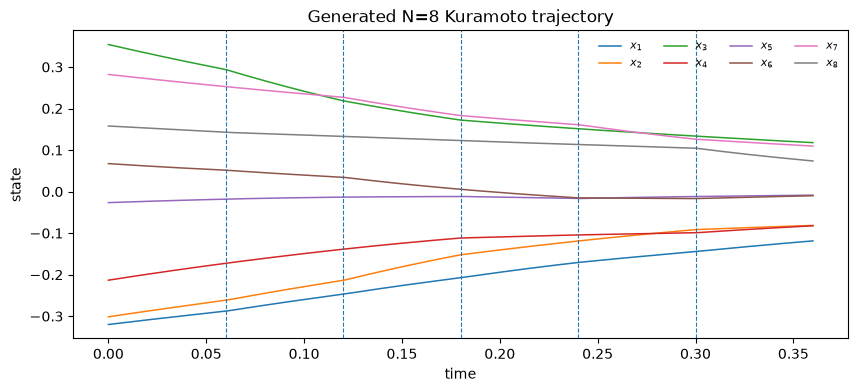

In [3]:

# ============================================================
# Cell 3 — Generate trajectory
# ============================================================
n_total_intervals = N_STAGES * INTERVALS_PER_STAGE
T = np.arange(n_total_intervals + 1, dtype=float) * DT
X = np.empty((n_total_intervals + 1, N), dtype=float)
X[0] = X0

true_stage_of_interval = np.repeat(
    np.arange(N_STAGES, dtype=int), INTERVALS_PER_STAGE
)
for n, stage in enumerate(true_stage_of_interval):
    X[n + 1] = rk4_step(X[n], DT, int(stage))

t = T.copy()

state_displacement = np.linalg.norm(X[-1] - X[0])
max_abs_state = np.max(np.abs(X))
net_sum_change = float(X[-1].sum() - X[0].sum())

print("=" * 90)
print("Kuramoto trajectory generated")
print("=" * 90)
print("X shape                :", X.shape)
print("||X(T)-X(0)||          :", f"{state_displacement:.6e}")
print("max |x_i(t)|           :", f"{max_abs_state:.6e}")
print("sum_i x_i change       :", f"{net_sum_change:.6e}")
print("all finite             :", np.isfinite(X).all())

assert X.shape == (721, 8)
assert np.allclose(np.diff(t), DT)
assert np.isfinite(X).all()
assert abs(net_sum_change) < 1e-10

fig, ax = plt.subplots(figsize=(10, 4))
for i in range(N):
    ax.plot(t, X[:, i], lw=1.1, label=f"$x_{i+1}$")
for tc in true_change_times:
    ax.axvline(tc, ls="--", lw=0.8)
ax.set_xlabel("time")
ax.set_ylabel("state")
ax.set_title("Generated N=8 Kuramoto trajectory")
ax.legend(ncol=4, fontsize=8, frameon=False)
plt.show()


In [4]:
# ============================================================
# Measurement-noise control
# MEASUREMENT_NOISE_REL = 0.0 disables noise; smoothing still differs from Notebook 04.
#
# Noise model:
#     X_obs = X_clean + sigma_m * xi,
#     xi ~ N(0,1) iid,
#     sigma_m = MEASUREMENT_NOISE_REL * RMS(X_clean).
#
# X_CLEAN is retained for validation.  Downstream cells continue
# to use observed X; preprocessing below jointly smooths states and derivatives.
# ============================================================

# Report recovery under noise without stopping at a truth mismatch.
# Set True only when intentionally running strict truth-recovery checks.
STRICT_TRUTH_CHECKS = False

MEASUREMENT_NOISE_SEED = 20260917
# MEASUREMENT_NOISE_REL = 0.0
MEASUREMENT_NOISE_REL = 1e-4

X_CLEAN = X.copy()
X_RMS = float(np.sqrt(np.mean(X_CLEAN**2)))
SIGMA_MEASUREMENT = float(MEASUREMENT_NOISE_REL * X_RMS)

measurement_noise_rng = np.random.default_rng(MEASUREMENT_NOISE_SEED)
MEASUREMENT_NOISE = (
    SIGMA_MEASUREMENT
    * measurement_noise_rng.standard_normal(X_CLEAN.shape)
)

X = X_CLEAN + MEASUREMENT_NOISE

print("=" * 90)
print("MEASUREMENT NOISE")
print("=" * 90)
print("relative noise level sigma_m / RMS(X) :", f"{MEASUREMENT_NOISE_REL:.12e}")
print("clean trajectory RMS                 :", f"{X_RMS:.12e}")
print("measurement-noise sigma              :", f"{SIGMA_MEASUREMENT:.12e}")
print("realized noise RMS                    :", f"{np.sqrt(np.mean(MEASUREMENT_NOISE**2)):.12e}")
print("max |measurement noise|               :", f"{np.max(np.abs(MEASUREMENT_NOISE)):.12e}")
print("noise disabled                        :", bool(MEASUREMENT_NOISE_REL == 0.0))

if MEASUREMENT_NOISE_REL == 0.0:
    assert np.array_equal(X, X_CLEAN)


MEASUREMENT NOISE
relative noise level sigma_m / RMS(X) : 1.000000000000e-04
clean trajectory RMS                 : 1.587733939907e-01
measurement-noise sigma              : 1.587733939907e-05
realized noise RMS                    : 1.579343984850e-05
max |measurement noise|               : 6.171401023940e-05
noise disabled                        : False


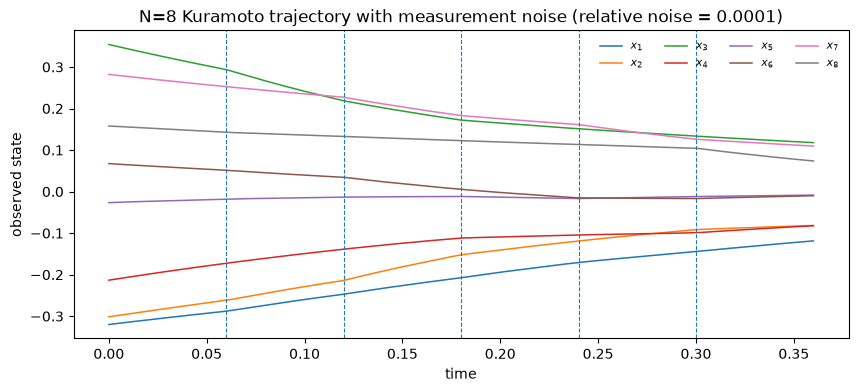

In [5]:
# ============================================================
# Plot trajectory after measurement noise
# ============================================================

fig, ax = plt.subplots(figsize=(10, 4))

for i in range(N):
    ax.plot(t, X[:, i], lw=1.1, label=f"$x_{i+1}$",)

for tc in true_change_times:
    ax.axvline(tc, ls="--", lw=0.8)

ax.set_xlabel("time")
ax.set_ylabel("observed state")
ax.set_title(
    "N=8 Kuramoto trajectory with measurement noise "
    f"(relative noise = {MEASUREMENT_NOISE_REL:g})")
ax.legend(ncol=4, fontsize=8, frameon=False)

plt.show()

STEP 1 — blind temporal segmentation
window size        : 5
window duration    : 2.500000e-03
MAD multiplier     : 8.0
jump median        : 4.604364322778e-02
jump MAD           : 8.127564288887e-03
robust scale       : 1.204992681470e-02
blind threshold    : 1.424430577454e-01
true indices       : [120 240 360 480 600]
detected indices   : [120 240 360 480 600]
detected times     : [0.06 0.12 0.18 0.24 0.3 ]
exact recovery     : True


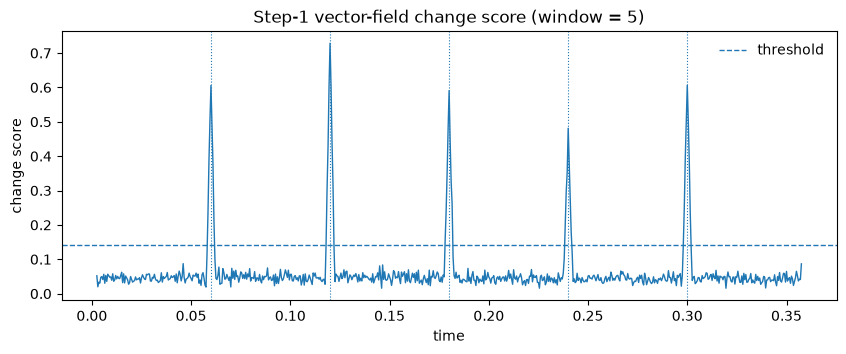

In [6]:
# ============================================================
# Cell 4 — Candidate-edge incidence + blind Step 1
# Window-averaged change detection
# ============================================================

M = len(CANDIDATE_EDGES)
D = np.zeros((N, M), dtype=float)

for m, (i, j) in enumerate(CANDIDATE_EDGES):
    D[i - 1, m] = -1.0
    D[j - 1, m] = +1.0


# ------------------------------------------------------------
# Step-1 controls
# ------------------------------------------------------------

STEP1_WINDOW = 5
STEP1_MAD_MULTIPLIER = 8.0


# ------------------------------------------------------------
# Blind change-point detection
# threshold=None lets detect_changes use its internal
# robust MAD threshold.
# ------------------------------------------------------------

s1_check = tides.detect_changes(
    X,
    t,
    method="window",
    window=STEP1_WINDOW,
    threshold=None,
    mad_multiplier=STEP1_MAD_MULTIPLIER,
    min_separation=1,
)


# ------------------------------------------------------------
# Recover the threshold value for diagnostics / plotting
# ------------------------------------------------------------

jump = s1_check.scores

jump_median = float(np.median(jump))
jump_mad = float(np.median(np.abs(jump - jump_median)))
jump_robust_scale = 1.4826 * jump_mad

blind_threshold = (
    jump_median
    + STEP1_MAD_MULTIPLIER * jump_robust_scale
)


# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------

print("=" * 90)
print("STEP 1 — blind temporal segmentation")
print("=" * 90)

print("window size        :", STEP1_WINDOW)
print("window duration    :", f"{STEP1_WINDOW * DT:.6e}")
print("MAD multiplier     :", STEP1_MAD_MULTIPLIER)
print("jump median        :", f"{jump_median:.12e}")
print("jump MAD           :", f"{jump_mad:.12e}")
print("robust scale       :", f"{jump_robust_scale:.12e}")
print("blind threshold    :", f"{blind_threshold:.12e}")
print("true indices       :", true_transition_indices)
print("detected indices   :", s1_check.transition_indices)
print("detected times     :", s1_check.transition_times)

step1_exact = np.array_equal(
    s1_check.transition_indices,
    true_transition_indices,
)

print("exact recovery     :", step1_exact)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 3.5))

ax.plot(
    s1_check.score_times,
    s1_check.scores,
    lw=1.0,
)

ax.axhline(
    blind_threshold,
    ls="--",
    lw=1.0,
    label="threshold",
)

for tc in true_change_times:
    ax.axvline(
        tc,
        ls=":",
        lw=0.8,
    )

ax.set_xlabel("time")
ax.set_ylabel("change score")
ax.set_title(
    f"Step-1 vector-field change score "
    f"(window = {STEP1_WINDOW})"
)

ax.legend(frameon=False)

plt.show()

## Common preprocessing: smoothing and epsilon calibration

Step 1 detects boundaries on the observed trajectory. Each detected stage is then
smoothed independently with a local polynomial in **time**, jointly producing midpoint
states and derivatives. Both libraries use this same `prep` object and `EPSILON`.

The epsilon calculation propagates fresh iid Gaussian measurement noise through the
same fixed smoother, then takes the 99% quantile of its **whole-vector derivative-error
norm** divided by the observed pairwise-target norm. Overlapping windows and shared
boundary samples retain their induced correlations. The known experimental noise
standard deviation is used; clean states, planted weights and the sine law are not.

An explicit relative margin covers a small additional error budget. It is a configurable
assumption for this example, not an automatically certified bound on smoothing bias,
state-input error or library approximation. The nominal quantile covers derivative
noise conditional on fixed segmentation and smoothing settings, not uncertainty in
detecting boundaries or choosing a window. The original four-vs-six-point audit is
not used to set the smoothed-data tolerance.


In [7]:
# ============================================================
# Cell 5 - Common smoothing and noise-calibrated epsilon
# ============================================================
SMOOTHING_KWARGS = dict(
    window_size=12,
    degree=3,                 # degree in TIME, independent of the law library
    boundary="shift",
    trim_intervals=1,
)
EPSILON_CONFIDENCE = 0.99
EPSILON_MC_SAMPLES = 5000
EPSILON_MC_BATCH_SIZE = 100
EPSILON_MC_SEED = 20260917
# Explicit additive allowance in relative-residual units, not a fitted quantity.
# Reassess this allowance for different noise levels/data/smoothing settings.
EPSILON_EXTRA_RELATIVE_MARGIN = 5.0e-4

prep = tides.preprocess_trajectory(
    X, t, s1_check.transition_indices,
    method="local_polynomial",
    resolution_audit=False,
    smoothing_kwargs={
        **SMOOTHING_KWARGS,
        "measurement_noise_std": SIGMA_MEASUREMENT,
    },
)


def calibrate_derivative_noise_epsilon(
    observed_X, times, transitions, preprocessed, *, measurement_sigma,
    smoothing_options, confidence, samples, batch_size, seed,
):
    """Whole-vector norm quantile for a fixed smoother and iid Gaussian noise.

    Replicates are batched as extra node columns; each keeps the original
    time samples, so smoothing-induced temporal correlations are preserved.
    This notebook has no intrinsic node term. A state-dependent intrinsic
    subtraction would need its own noise propagation as well.
    """
    if not 0.0 < confidence < 1.0:
        raise ValueError("confidence must lie strictly between zero and one")
    if samples < 1 or batch_size < 1:
        raise ValueError("samples and batch_size must be positive")
    if not np.isfinite(measurement_sigma) or measurement_sigma < 0.0:
        raise ValueError("measurement_sigma must be finite and nonnegative")
    target_norm = float(np.linalg.norm(preprocessed.pairwise_target))
    if not np.isfinite(target_norm) or target_norm <= 0.0:
        raise ValueError("relative epsilon requires a nonzero finite target")
    n_samples, n_nodes = observed_X.shape
    rng = np.random.default_rng(seed)
    relative_norms = np.empty(samples, dtype=float)
    for first in range(0, samples, batch_size):
        count = min(batch_size, samples - first)
        noise = rng.normal(0.0, measurement_sigma,
                           size=(n_samples, count * n_nodes))
        simulated = tsmooth.smooth_segmented_trajectory(
            noise, times, transitions, **smoothing_options,
        )
        np.testing.assert_array_equal(
            simulated.observation_interval_indices,
            preprocessed.observation_interval_indices,
        )
        errors = simulated.velocity_mid.reshape(
            preprocessed.n_observations, count, n_nodes,
        )
        relative_norms[first:first + count] = (
            np.sqrt(np.sum(errors * errors, axis=(0, 2))) / target_norm
        )
    return {
        "epsilon_noise": float(np.quantile(relative_norms, confidence)),
        "confidence": confidence,
        "samples": samples,
        "seed": seed,
        "measurement_sigma": float(measurement_sigma),
        "target_norm": target_norm,
        "expected_relative_noise_rms": float(
            np.linalg.norm(preprocessed.smoothing.velocity_noise_std) / target_norm
        ),
        "simulated_relative_noise_rms": float(np.sqrt(np.mean(relative_norms**2))),
        "relative_noise_norms": relative_norms,
    }


calibration_started = time.perf_counter()
EPSILON_CALIBRATION = calibrate_derivative_noise_epsilon(
    X, t, s1_check.transition_indices, prep,
    measurement_sigma=SIGMA_MEASUREMENT,
    smoothing_options=SMOOTHING_KWARGS,
    confidence=EPSILON_CONFIDENCE,
    samples=EPSILON_MC_SAMPLES,
    batch_size=EPSILON_MC_BATCH_SIZE,
    seed=EPSILON_MC_SEED,
)
if (not np.isfinite(EPSILON_EXTRA_RELATIVE_MARGIN)
        or EPSILON_EXTRA_RELATIVE_MARGIN < 0.0):
    raise ValueError("epsilon margin must be finite and nonnegative")
EPSILON_NOISE = EPSILON_CALIBRATION["epsilon_noise"]
EPSILON = float(EPSILON_NOISE + EPSILON_EXTRA_RELATIVE_MARGIN)
EPSILON_CALIBRATION.update(
    extra_relative_margin=EPSILON_EXTRA_RELATIVE_MARGIN,
    epsilon=EPSILON,
    smoothing_options=SMOOTHING_KWARGS.copy(),
)

tail = np.array([i - 1 for i, _ in CANDIDATE_EDGES], dtype=int)
head = np.array([j - 1 for _, j in CANDIDATE_EDGES], dtype=int)
d_all_matrix = prep.x_mid[:, head] - prep.x_mid[:, tail]
d_all = d_all_matrix.ravel()

print("=" * 90)
print("COMMON SMOOTHING / EPSILON CALIBRATION")
print("=" * 90)
print("smoothing settings          :", SMOOTHING_KWARGS)
print("midpoint state shape        :", prep.x_mid.shape)
print("midpoint derivative shape   :", prep.velocity_mid.shape)
print("samples / stage             :", prep.samples_per_stage.tolist())
print("known measurement sigma     :", f"{SIGMA_MEASUREMENT:.12e}")
print("predicted derivative RMS    :", f"{prep.smoothing.expected_velocity_noise_rms:.12e}")
print("noise norm confidence       :", EPSILON_CONFIDENCE)
print("Monte Carlo samples / seed  :", EPSILON_MC_SAMPLES, "/", EPSILON_MC_SEED)
print("noise-only epsilon          :", f"{EPSILON_NOISE:.12e}")
print("extra relative margin       :", f"{EPSILON_EXTRA_RELATIVE_MARGIN:.12e}")
print("common final epsilon        :", f"{EPSILON:.12e}")
print("calibration elapsed / s     :", f"{time.perf_counter()-calibration_started:.3f}")
print("max |phase difference|      :", f"{np.max(np.abs(d_all)):.12e}")
print("RMS phase difference        :", f"{np.sqrt(np.mean(d_all**2)):.12e}")

assert prep.x_mid.shape == prep.velocity_mid.shape == (prep.n_observations, N)
assert np.all(prep.samples_per_stage > 0)
assert np.isfinite(EPSILON) and EPSILON > 0.0


COMMON SMOOTHING / EPSILON CALIBRATION
smoothing settings          : {'window_size': 12, 'degree': 3, 'boundary': 'shift', 'trim_intervals': 1}
midpoint state shape        : (708, 8)
midpoint derivative shape   : (708, 8)
samples / stage             : [118, 118, 118, 118, 118, 118]
known measurement sigma     : 1.587733939907e-05
predicted derivative RMS    : 6.852451231198e-03
noise norm confidence       : 0.99
Monte Carlo samples / seed  : 5000 / 20260917
noise-only epsilon          : 1.443805554839e-02
extra relative margin       : 5.000000000000e-04
common final epsilon        : 1.493805554839e-02
calibration elapsed / s     : 4.933
max |phase difference|      : 6.728524355424e-01
RMS phase difference        : 2.399665606156e-01



## Path A — relative-polynomial library

This is the dynamics-agnostic reconstruction path used in the previous benchmark:

\[
z=\frac{x_j-x_i}{s},
\qquad
\Psi_{\rm poly}=\{z,z^2,\ldots,z^{11}\}.
\]

The planted sine law is not supplied as an atom; its observed-domain representation is reconstructed through polynomial coefficients.


In [8]:

# ============================================================
# Cell 6A — Build and audit the relative-polynomial library
# ============================================================
POLY_DEGREE = 11

POLY_LIBRARY = tides.build_interaction_library(
    prep.x_mid,
    D,
    mode="relative_polynomial",
    degree=POLY_DEGREE,
    check_sampled_swap_equivariance=True,
)

L_POLY = POLY_LIBRARY.n_features
DIFF_SCALE = float(
    POLY_LIBRARY.metadata["atom_metadata"][0]["difference_scale"]
)

THETA_TAYLOR_GAUGE = np.zeros(L_POLY, dtype=float)
for p in range(1, L_POLY + 1):
    if p % 2 == 1:
        k = (p - 1) // 2
        THETA_TAYLOR_GAUGE[p - 1] = (
            ((-1.0) ** k) * DIFF_SCALE ** (p - 1) / math.factorial(p)
        )

z_all = d_all / DIFF_SCALE
f_taylor_phys = DIFF_SCALE * sum(
    THETA_TAYLOR_GAUGE[p - 1] * z_all**p
    for p in range(1, L_POLY + 1)
)
f_true = np.sin(d_all)
taylor_rel_error = (
    np.linalg.norm(f_taylor_phys - f_true) / np.linalg.norm(f_true)
)

print("=" * 90)
print("PATH A — RELATIVE-POLYNOMIAL LIBRARY")
print("=" * 90)
print("requested path                : relative_polynomial")
print("library object mode           :", POLY_LIBRARY.mode)
print("MDL mode                      :", POLY_LIBRARY.metadata.get("mdl_mode"))
print("feature shape                 :", POLY_LIBRARY.endpoint_features.shape)
print("feature labels                :", POLY_LIBRARY.feature_labels)
print("difference scale s            :", f"{DIFF_SCALE:.12e}")
print("Taylor gauge theta            :", np.array2string(THETA_TAYLOR_GAUGE, precision=12))
print("degree-11 Taylor law rel.err  :", f"{taylor_rel_error:.12e}")

assert L_POLY == 11
assert POLY_LIBRARY.endpoint_features.shape == (prep.n_observations, M, 11, 2)
assert POLY_LIBRARY.metadata.get("mdl_mode") == "polynomial"
assert np.isclose(THETA_TAYLOR_GAUGE[0], 1.0)


PATH A — RELATIVE-POLYNOMIAL LIBRARY
requested path                : relative_polynomial
library object mode           : candidate
MDL mode                      : polynomial
feature shape                 : (708, 28, 11, 2)
feature labels                : ('rel_d^1', 'rel_d^2', 'rel_d^3', 'rel_d^4', 'rel_d^5', 'rel_d^6', 'rel_d^7', 'rel_d^8', 'rel_d^9', 'rel_d^10', 'rel_d^11')
difference scale s            : 6.728524355424e-01
Taylor gauge theta            : [ 1.000000000000e+00  0.000000000000e+00 -7.545506666923e-02
  0.000000000000e+00  1.708040125817e-03  0.000000000000e+00
 -1.841146879532e-05  0.000000000000e+00  1.157698837858e-07
  0.000000000000e+00 -4.764776890552e-10]
degree-11 Taylor law rel.err  : 1.965422834123e-13



## Path B — candidate physical-mechanism library

The candidate path works directly in physical, unnormalised phase differences. The default test dictionary is declared explicitly:

\[
\Psi_{\rm cand}
=
\{
x_j-x_i,\;
\sin(x_j-x_i),\;
\tanh(x_j-x_i),\;
(x_j-x_i)^3
\}.
\]

For the planted Kuramoto generator the exact candidate-space truth is a pure sine atom.


In [9]:

# ============================================================
# Cell 6B — Build and audit the candidate library
# ============================================================
CANDIDATE_ATOMS = plib.common_candidate_atoms(
    "difference",
    harmonics=(1,),
)

CAND_LIBRARY = tides.build_interaction_library(
    prep.x_mid,
    D,
    mode="candidate",
    atoms=CANDIDATE_ATOMS,
    check_sampled_swap_equivariance=True,
)

L_CAND = CAND_LIBRARY.n_features
CAND_LABELS = CAND_LIBRARY.feature_labels
SIN_ATOM = CAND_LABELS.index("sin_difference")

THETA_TRUE_CANDIDATE = np.zeros(L_CAND, dtype=float)
THETA_TRUE_CANDIDATE[SIN_ATOM] = 1.0

sin_feature = CAND_LIBRARY.endpoint_features[:, :, SIN_ATOM, :]
sin_true_tail = np.sin(d_all_matrix)
sin_true_head = -np.sin(d_all_matrix)

sin_tail_rel_error = (
    np.linalg.norm(sin_feature[:, :, 0] - sin_true_tail)
    / np.linalg.norm(sin_true_tail)
)
sin_head_rel_error = (
    np.linalg.norm(sin_feature[:, :, 1] - sin_true_head)
    / np.linalg.norm(sin_true_head)
)
sin_antisymmetry_error = (
    np.linalg.norm(sin_feature[:, :, 0] + sin_feature[:, :, 1])
    / np.linalg.norm(sin_feature[:, :, 0])
)

print("=" * 90)
print("PATH B — CANDIDATE LIBRARY")
print("=" * 90)
print("library mode                  :", CAND_LIBRARY.mode)
print("MDL mode                      :", CAND_LIBRARY.metadata.get("mdl_mode"))
print("feature shape                 :", CAND_LIBRARY.endpoint_features.shape)
print("feature labels                :", CAND_LABELS)
print("ground-truth sine atom index  :", SIN_ATOM)
print("candidate truth theta         :", THETA_TRUE_CANDIDATE)
print("sine tail evaluation rel.err  :", f"{sin_tail_rel_error:.12e}")
print("sine head evaluation rel.err  :", f"{sin_head_rel_error:.12e}")
print("sine antisymmetry rel.err     :", f"{sin_antisymmetry_error:.12e}")

assert L_CAND == 4
assert CAND_LIBRARY.endpoint_features.shape == (prep.n_observations, M, 4, 2)
assert CAND_LIBRARY.metadata.get("mdl_mode") == "candidate"
assert sin_tail_rel_error < 1e-14
assert sin_head_rel_error < 1e-14
assert sin_antisymmetry_error < 1e-14


PATH B — CANDIDATE LIBRARY
library mode                  : candidate
MDL mode                      : candidate
feature shape                 : (708, 28, 4, 2)
feature labels                : ('linear_difference', 'sin_difference', 'tanh_difference_s1.0', 'cubic_difference')
ground-truth sine atom index  : 1
candidate truth theta         : [0. 1. 0. 0.]
sine tail evaluation rel.err  : 0.000000000000e+00
sine head evaluation rel.err  : 0.000000000000e+00
sine antisymmetry rel.err     : 0.000000000000e+00



## Step 2 — same reconstruction API, two libraries

Both evaluated libraries are passed to exactly the same Step-2 reconstruction routine. The resulting objects have the same `EdgeSpaceFieldFamily` interface; only the library dimension and basis interpretation differ.


In [10]:

# ============================================================
# Cell 7 — Step 2 for both library paths
# ============================================================
STEP2_KWARGS = {
    "design_mode": "dense",
    "solver_method": "dense_lstsq",
}

t0 = time.perf_counter()
POLY_FAMILY, _ = tides.run_tides_from_observations(
    prep.pairwise_target,
    D,
    POLY_LIBRARY,
    prep.stage_of_observation,
    uncertainty_floor=EPSILON,
    run_physical_compression=False,
    step2_kwargs=STEP2_KWARGS,
)
poly_step2_elapsed = time.perf_counter() - t0

t0 = time.perf_counter()
CAND_FAMILY, _ = tides.run_tides_from_observations(
    prep.pairwise_target,
    D,
    CAND_LIBRARY,
    prep.stage_of_observation,
    uncertainty_floor=EPSILON,
    run_physical_compression=False,
    step2_kwargs=STEP2_KWARGS,
)
cand_step2_elapsed = time.perf_counter() - t0


def print_family_audit(name, family, expected_L):
    print("\n" + "=" * 90)
    print(f"STEP 2 — {name}")
    print("=" * 90)
    print("reference B shape         :", family.reference_B_stages.shape)
    print("parameter count           :", family.parameter_count)
    print("rank                      :", family.rank)
    print("nullity                   :", family.nullity)
    print("minimum relative residual :", f"{family.minimum_relative_residual:.12e}")
    print("uncertainty floor         :", f"{family.uncertainty_floor:.12e}")
    print("slack^2                   :", f"{family.slack_squared:.12e}")
    print("stage ranks               :", [g.rank for g in family.stage_geometry])
    print("stage nullities           :", [g.nullity for g in family.stage_geometry])

    assert family.reference_B_stages.shape == (6, 28, expected_L)
    assert family.parameter_count == 6 * 28 * expected_L
    assert family.rank is not None and family.nullity is not None
    assert family.rank + family.nullity == family.parameter_count
    assert family.minimum_relative_residual <= family.uncertainty_floor
    assert not family.is_empty


print_family_audit("RELATIVE POLYNOMIAL", POLY_FAMILY, L_POLY)
print("elapsed / s               :", f"{poly_step2_elapsed:.3f}")

print_family_audit("CANDIDATE", CAND_FAMILY, L_CAND)
print("elapsed / s               :", f"{cand_step2_elapsed:.3f}")

# Explicitly exhibit alternative members of each observational family.
POLY_B_ALT = POLY_FAMILY.sample_feasible(
    rng=np.random.default_rng(20260916),
    null_scale=1.0,
    boundary_fraction=0.85,
)
CAND_B_ALT = CAND_FAMILY.sample_feasible(
    rng=np.random.default_rng(20260917),
    null_scale=1.0,
    boundary_fraction=0.85,
)

assert POLY_FAMILY.is_feasible(POLY_B_ALT)
assert CAND_FAMILY.is_feasible(CAND_B_ALT)

print("\nAlternative-family-member checks")
print(
    "poly  : distance / rho =",
    f"{np.linalg.norm(POLY_B_ALT - POLY_FAMILY.reference_B_stages):.6e}",
    "/",
    f"{POLY_FAMILY.relative_residual(POLY_B_ALT):.6e}",
)
print(
    "cand  : distance / rho =",
    f"{np.linalg.norm(CAND_B_ALT - CAND_FAMILY.reference_B_stages):.6e}",
    "/",
    f"{CAND_FAMILY.relative_residual(CAND_B_ALT):.6e}",
)



STEP 2 — RELATIVE POLYNOMIAL
reference B shape         : (6, 28, 11)
parameter count           : 1848
rank                      : 1788
nullity                   : 60
minimum relative residual : 8.787169445417e-03
uncertainty floor         : 1.493805554839e-02
slack^2                   : 2.015366924410e-01
stage ranks               : [303, 306, 304, 292, 290, 293]
stage nullities           : [5, 2, 4, 16, 18, 15]
elapsed / s               : 0.283

STEP 2 — CANDIDATE
reference B shape         : (6, 28, 4)
parameter count           : 672
rank                      : 551
nullity                   : 121
minimum relative residual : 1.366065881743e-02
uncertainty floor         : 1.493805554839e-02
slack^2                   : 5.045200295473e-02
stage ranks               : [97, 96, 95, 89, 88, 86]
stage nullities           : [15, 16, 17, 23, 24, 26]
elapsed / s               : 0.067

Alternative-family-member checks
poly  : distance / rho = 2.595468e+16 / 1.493799e-02
cand  : distance / rho = 4


## Step 3 — one physical-compression API

Both Step-2 families enter the same fixed-dynamics hypothesis

\[
B^{(r)}=W^{(r)}\Theta^\top.
\]

The same structural coordinates are used in both cases:

\[
W^{(1)},\Delta W^{(1)},\ldots,\Delta W^{(5)}.
\]

The common Step-3 wrapper below deliberately does not specify `initial_atoms`.

- For the polynomial library this triggers the ordinary shared-coefficient search.
- For the candidate library the updated search code first screens each pure candidate law under the maximal structural dictionary, completes every continuously feasible branch, and compares their final MDL values.

The structural-search and precision budgets are otherwise shared.

### Simulated annealing (single chain in this notebook)

Each continuously feasible pure-law seed is processed before comparing complete
MDL scores. Each chain first uses the previous alternating method as a warm start,
then performs up to `max_mdl_search_rounds` SA proposals. Warm-start budgets are
separate. Feasible proposals with higher MDL may be accepted with probability
`2**(-delta_bits / temperature_bits)`; the best feasible model is always retained.
This is heuristic optimization, not exact posterior sampling. A failed fit or
quantization does not establish infeasibility or count as stability evidence.

`sa_options['n_chains']` reserves independent multi-chain runs (currently serial).
Comparison reports check support and quantized parameter agreement separately;
similar DL alone does not mean the same model or prove global optimality.
The temperature settings are initial experimental choices, not tuned to truth.
Restart the server kernel after uploading the updated Python modules.


In [ ]:

# ============================================================
# Cell 8 — Common Step-3 wrapper
# ============================================================
STEP3_KWARGS = dict(
    quantizer_bound=8.0,
    search_strategy="simulated_annealing",

    # Warm-start Stage A — shared-law / branch basin.
    n_basin_hops=10,
    basin_seed=20260916,
    basin_local_max_nfev=50,

    # SA budget and warm-start Stage B — structural screen -> joint refinement.
    max_mdl_search_rounds=200,  # SA proposals per chain / feasible law branch
    sa_options=dict(
        n_chains=1,                 # independent chains; serial execution for now
        seed=20260918,
        initial_temperature_bits=10.0,
        final_temperature_bits=0.1,
        min_rounds=60,
        patience_rounds=40,
        improvement_abs_bits=0.1,
        improvement_rel_tol=1e-4,
        min_unique_proposals=5,
        warm_start_rounds=5,         # separate alternating-search initialization
        batch_probability=0.25,     # remaining proposals: random add/drop/swap
        progress_interval=20,
    ),
    structural_joint_candidates=1,
    structural_beyond_boundary=0,
    structural_polish_sweeps=1,

    # Warm-start Stage C — interaction-expression compression / expansion.
    max_expression_sweeps=8,

    # Joint / precision controls.
    q_min=1,
    q_max=64,
    max_nfev=50,
    final_max_nfev=100,
    max_coordinate_passes=1,

    # Warm-start shortlists only. SA uses random bidirectional proposals,
    # independent of these top-k limits.
    top_group_drops=1,
    top_group_adds=1,
    top_group_swaps=1,
    top_atom_drops=1,
    top_atom_adds=1,
    top_atom_swaps=1,
)


def run_step3(name, family):
    print("\n" + "=" * 90)
    print(f"STEP 3 START — {name}")
    print("=" * 90)

    t0 = time.perf_counter()
    result = step3pc.compress_fixed_dynamics(
        family,
        **STEP3_KWARGS,
    )
    elapsed = time.perf_counter() - t0

    print("elapsed / s                 :", f"{elapsed:.3f}")
    print("search strategy             :", result.search_result.search_strategy)
    print("initial structural groups   :", len(result.search_result.initial_state.active_groups))
    print("final structural groups     :", len(result.search_result.best_state.active_groups))
    print("structural accepted moves   :", len(result.search_result.structural_history))
    print("expression accepted moves   :", len(result.search_result.expression_history))
    print("final active atoms          :", result.active_atoms)
    print("continuous residual         :", f"{result.continuous_relative_residual:.12e}")
    print("finite-precision residual   :", f"{result.relative_residual:.12e}")
    print("uncertainty floor           :", f"{result.uncertainty_floor:.12e}")
    print("q upper bound               :", result.q_upper)
    print("initial MDL / bits          :", f"{result.search_result.initial_state.mdl_upper.total_bits:.3f}")
    print("final MDL / bits            :", f"{result.mdl_score.total_bits:.3f}")
    print(
        "anchor -> final theta drift :",
        f"{result.metadata['theta_anchor_to_final_relative_change']:.12e}",
    )

    assert result.feasible
    assert len(result.search_result.initial_state.active_groups) == 168
    assert family.is_feasible(result.B_stages)
    print("code-domain seed diagnostic :",
          result.metadata.get("initial_precision_diagnostics"))

    for chain in result.search_result.sa_chains:
        print("SA chain / seed / rounds / stop :", chain["chain_id"], chain["seed"],
              chain["rounds"], chain["stop_reason"])
        print("  best / final-current MDL bits :", chain["best_mdl_bits"], chain["current_mdl_bits"])
        print("  feasible / uphill accepted    :", chain["feasible_proposals"], chain["accepted_uphill"])
    chains = result.search_result.sa_chains
    if len(chains) == 1:
        print("Single chain: cross-chain agreement cannot yet be assessed.")
    for i in range(len(chains)):
        for j in range(i + 1, len(chains)):
            a, b = chains[i], chains[j]
            same_support = a["best_groups"] == b["best_groups"] and a["best_atoms"] == b["best_atoms"]
            same_parameters = same_support and np.allclose(a["best_theta"], b["best_theta"], rtol=1e-6, atol=1e-8) and np.allclose(a["best_amplitudes"], b["best_amplitudes"], rtol=1e-6, atol=1e-8)
            print("Chain comparison", i, j, "same support:", same_support,
                  "same quantized parameters:", same_parameters,
                  "MDL gap / bits:", abs(a["best_mdl_bits"] - b["best_mdl_bits"]))
    return result, elapsed


In [ ]:
print("=" * 90)
print("NOISY UNCERTAINTY DIAGNOSTIC")
print("=" * 90)

print("measurement noise rel      :", MEASUREMENT_NOISE_REL)
print("smoothing settings         :", SMOOTHING_KWARGS)
print("noise-only epsilon         :", f"{EPSILON_NOISE:.12e}")
print("extra relative margin      :", EPSILON_EXTRA_RELATIVE_MARGIN)
print("epsilon                    :", f"{EPSILON:.12e}")

print("\nPOLYNOMIAL STEP 2")
print(
    "minimum residual           :",
    f"{POLY_FAMILY.minimum_relative_residual:.12e}"
)
print(
    "epsilon - minimum residual :",
    f"{EPSILON - POLY_FAMILY.minimum_relative_residual:.12e}"
)

print("\nCANDIDATE STEP 2")
print(
    "minimum residual           :",
    f"{CAND_FAMILY.minimum_relative_residual:.12e}"
)
print(
    "epsilon - minimum residual :",
    f"{EPSILON - CAND_FAMILY.minimum_relative_residual:.12e}"
)

In [ ]:

# ============================================================
# Cell 9A — Run Step 3: relative-polynomial path
# ============================================================
POLY_RESULT, poly_step3_elapsed = run_step3(
    "RELATIVE POLYNOMIAL",
    POLY_FAMILY,
)

print("\nAccepted polynomial path:")
for h in POLY_RESULT.search_result.history:
    print(
        f"  {h.phase:18s} | {h.move.label():18s} | "
        f"{h.old_mdl_upper / np.log(2):9.3f} -> "
        f"{h.new_mdl_upper / np.log(2):9.3f} bits | "
        f"dtheta={h.theta_relative_change if h.theta_relative_change is not None else np.nan:.3e}"
    )


In [ ]:

# ============================================================
# Cell 9B — Run Step 3: candidate path
# ============================================================
CAND_RESULT, cand_step3_elapsed = run_step3(
    "CANDIDATE",
    CAND_FAMILY,
)

print("\nCandidate pure-law branch audit:")
branches = CAND_RESULT.search_result.candidate_branches

if not branches:
    print("  No candidate-branch summary found.")
else:
    for b in branches:
        seed_name = CAND_LABELS[b.seed_atom]
        final_names = tuple(CAND_LABELS[a] for a in b.final_atoms)
        initial_bits = (
            np.nan if b.initial_mdl is None else b.initial_mdl / np.log(2)
        )
        final_bits = (
            np.nan if b.final_mdl is None else b.final_mdl / np.log(2)
        )
        print(
            f"  {seed_name:24s} | "
            f"rho_dense={b.initial_relative_residual:.6e} | "
            f"status={b.status:28s} | "
            f"MDL {initial_bits:9.3f} -> {final_bits:9.3f} bits | "
            f"final atoms={final_names} | "
            f"groups={len(b.final_groups)}"
        )

print("\nSA diagnostics for every completed pure-law branch:")
for b in branches:
    for chain in b.sa_chains:
        print(CAND_LABELS[b.seed_atom], "chain", chain["chain_id"],
              "rounds", chain["rounds"], "stop", chain["stop_reason"],
              "best bits", chain["best_mdl_bits"])

print("\nAccepted candidate path:")
for h in CAND_RESULT.search_result.history:
    print(
        f"  {h.phase:18s} | {h.move.label():18s} | "
        f"{h.old_mdl_upper / np.log(2):9.3f} -> "
        f"{h.new_mdl_upper / np.log(2):9.3f} bits | "
        f"dtheta={h.theta_relative_change if h.theta_relative_change is not None else np.nan:.3e}"
    )



## Common structural validation

Topology and temporal-change supports have the same physical meaning in both library modes, so support validation is shared.

For this noisy experiment, truth recovery is reported as a result. `STRICT_TRUTH_CHECKS=True` optionally restores the original strict assertions; numerical feasibility checks remain mandatory.


In [ ]:

# ============================================================
# Cell 10 — Common topology-support validation
# ============================================================
TRUE_BASELINE_INDEX = tuple(sorted(EDGE_INDEX_1B[e] for e in SNAPSHOTS[0]))
TRUE_CHANGE_INDEX = tuple(
    tuple(sorted(EDGE_INDEX_1B[e] for e in support))
    for support in transition_supports_true
)


def validate_supports(name, result):
    baseline_recovered = tuple(result.baseline_support.tolist())
    change_recovered = tuple(tuple(s.tolist()) for s in result.change_supports)

    baseline_exact = baseline_recovered == TRUE_BASELINE_INDEX
    changes_exact = tuple(
        inferred == truth
        for inferred, truth in zip(change_recovered, TRUE_CHANGE_INDEX)
    )

    print("\n" + "=" * 90)
    print(f"STRUCTURAL RECOVERY — {name}")
    print("=" * 90)
    print("baseline truth     :", TRUE_BASELINE_INDEX)
    print("baseline recovered :", baseline_recovered)
    print("baseline exact     :", baseline_exact)

    for k, (truth, inferred, ok) in enumerate(
        zip(TRUE_CHANGE_INDEX, change_recovered, changes_exact), 1
    ):
        print(f"\nDelta-W transition {k}")
        print("  truth     :", truth)
        print("  recovered :", inferred)
        print("  exact     :", ok)

    if STRICT_TRUTH_CHECKS:
        assert baseline_exact
        assert all(changes_exact)
        assert len(result.baseline_support) == 10
        assert [len(s) for s in result.change_supports] == [4, 4, 4, 4, 4]

    return baseline_exact, changes_exact


POLY_BASELINE_EXACT, POLY_CHANGES_EXACT = validate_supports(
    "RELATIVE POLYNOMIAL",
    POLY_RESULT,
)
CAND_BASELINE_EXACT, CAND_CHANGES_EXACT = validate_supports(
    "CANDIDATE",
    CAND_RESULT,
)

print("\nBoth paths recover planted supports exactly:",
      POLY_BASELINE_EXACT and all(POLY_CHANGES_EXACT)
      and CAND_BASELINE_EXACT and all(CAND_CHANGES_EXACT))


In [ ]:
# ============================================================
# Diagnostic A — exact planted-model residual after smoothing
# ============================================================

Y_TRUE_PLANTED = np.vstack([
    stage_field(x, int(stage))
    for x, stage in zip(
        prep.x_mid,
        prep.stage_of_observation,
    )
])

Y_OBS = prep.pairwise_target

RHO_TRUE_PLANTED = (
    np.linalg.norm(Y_OBS - Y_TRUE_PLANTED)
    / np.linalg.norm(Y_OBS)
)

print("=" * 90)
print("PLANTED-MODEL FEASIBILITY")
print("=" * 90)
print("planted residual :", f"{RHO_TRUE_PLANTED:.12e}")
print("epsilon          :", f"{EPSILON:.12e}")
print("slack            :", f"{EPSILON - RHO_TRUE_PLANTED:.12e}")
print("planted feasible :", RHO_TRUE_PLANTED <= EPSILON)

In [ ]:
# ============================================================
# Diagnostic B — profile amplitudes on the TRUE structural support
#                 with the TRUE pure-sine law
# ============================================================

TRUE_BASELINE_INDEX = tuple(
    sorted(EDGE_INDEX_1B[e] for e in SNAPSHOTS[0])
)

TRUE_CHANGE_INDEX = tuple(
    tuple(sorted(EDGE_INDEX_1B[e] for e in support))
    for support in transition_supports_true
)

TRUE_GROUPS = (
    [("baseline", m) for m in TRUE_BASELINE_INDEX]
    +
    [
        ("transition", k, m)
        for k, support in enumerate(TRUE_CHANGE_INDEX)
        for m in support
    ]
)

assert len(TRUE_GROUPS) == 30


def unit_sine_edge_output(x, edge_index):
    i, j = CANDIDATE_EDGES[edge_index]
    i -= 1
    j -= 1

    q = np.sin(x[j] - x[i])

    out = np.zeros(N, dtype=float)
    out[i] += q
    out[j] -= q
    return out


columns = []

for group in TRUE_GROUPS:
    pieces = []

    for x, stage in zip(
        prep.x_mid,
        prep.stage_of_observation,
    ):
        stage = int(stage)

        if group[0] == "baseline":
            _, m = group
            active = True

        else:
            _, k, m = group
            active = stage > k

        if active:
            pieces.append(
                unit_sine_edge_output(x, m)
            )
        else:
            pieces.append(
                np.zeros(N, dtype=float)
            )

    columns.append(np.concatenate(pieces))


C_TRUE = np.column_stack(columns)
y = prep.pairwise_target.ravel()

a_true_profiled, *_ = np.linalg.lstsq(
    C_TRUE,
    y,
    rcond=None,
)

rho_true_support = (
    np.linalg.norm(y - C_TRUE @ a_true_profiled)
    / np.linalg.norm(y)
)

print("=" * 90)
print("TRUE-SUPPORT PROFILED FEASIBILITY")
print("=" * 90)
print("number of groups :", len(TRUE_GROUPS))
print("profiled residual:", f"{rho_true_support:.12e}")
print("epsilon          :", f"{EPSILON:.12e}")
print("slack            :", f"{EPSILON - rho_true_support:.12e}")
print("support feasible :", rho_true_support <= EPSILON)


## Path-specific dynamics validation

The topology is common, but the \(\Theta\) coordinates are not.

For the relative-polynomial path, the gauge \(\theta_1=1\) implies planted active structural amplitudes

\[
W^{\rm poly}_{m}=sA_m.
\]

For the pure sine candidate path,

\[
\Theta_{\rm cand}=e_{\sin},
\]

so the structural amplitude is directly the physical Kuramoto edge weight,

\[
W^{\rm cand}_{m}=A_m.
\]


In [ ]:

# ============================================================
# Cell 11A — Polynomial dynamics + amplitude audit
# ============================================================
poly_theta_anchor = np.asarray(
    POLY_RESULT.search_result.theta_anchor,
    dtype=float,
)
poly_theta_final = np.asarray(
    POLY_RESULT.continuous_theta,
    dtype=float,
)

poly_theta_anchor_rel = (
    np.linalg.norm(poly_theta_anchor - THETA_TAYLOR_GAUGE)
    / np.linalg.norm(THETA_TAYLOR_GAUGE)
)

poly_theta_reference_selected = THETA_TAYLOR_GAUGE.copy()
for a in range(L_POLY):
    if a not in POLY_RESULT.active_atoms:
        poly_theta_reference_selected[a] = 0.0

poly_theta_final_rel = (
    np.linalg.norm(poly_theta_final - poly_theta_reference_selected)
    / np.linalg.norm(poly_theta_reference_selected)
)

W_TRUE_POLY = np.zeros((N_STAGES, M), dtype=float)
for r, snapshot in enumerate(SNAPSHOTS):
    for edge in snapshot:
        W_TRUE_POLY[r, EDGE_INDEX_1B[edge]] = DIFF_SCALE * EDGE_WEIGHT[edge]

dW_TRUE_POLY = np.diff(W_TRUE_POLY, axis=0)
active_W_poly = W_TRUE_POLY != 0.0
active_dW_poly = dW_TRUE_POLY != 0.0

poly_W_cont_rel = (
    np.linalg.norm(
        (POLY_RESULT.continuous_W_stages - W_TRUE_POLY)[active_W_poly]
    )
    / np.linalg.norm(W_TRUE_POLY[active_W_poly])
)
poly_dW_cont_rel = (
    np.linalg.norm(
        (
            np.diff(POLY_RESULT.continuous_W_stages, axis=0)
            - dW_TRUE_POLY
        )[active_dW_poly]
    )
    / np.linalg.norm(dW_TRUE_POLY[active_dW_poly])
)
poly_inactive_W_max = float(
    np.max(np.abs(POLY_RESULT.continuous_W_stages[~active_W_poly]))
)

poly_active_powers = tuple(a + 1 for a in POLY_RESULT.active_atoms)

print("=" * 90)
print("POLYNOMIAL DYNAMICS / AMPLITUDE AUDIT")
print("=" * 90)
print("theta anchor vs Taylor rel.err :", f"{poly_theta_anchor_rel:.12e}")
print("theta final vs selected ref    :", f"{poly_theta_final_rel:.12e}")
print("anchor -> final theta drift    :", f"{POLY_RESULT.metadata['theta_anchor_to_final_relative_change']:.12e}")
print("continuous W rel.err           :", f"{poly_W_cont_rel:.12e}")
print("continuous Delta-W rel.err     :", f"{poly_dW_cont_rel:.12e}")
print("max inactive continuous |W|    :", f"{poly_inactive_W_max:.12e}")
print("active polynomial powers       :", poly_active_powers)

if STRICT_TRUTH_CHECKS:
    assert poly_theta_anchor_rel < 1e-6
    assert poly_theta_final_rel < 1e-6
    assert poly_W_cont_rel < 1e-8
    assert poly_dW_cont_rel < 1e-8
    assert poly_inactive_W_max < 1e-8
    assert all(p % 2 == 1 for p in poly_active_powers)

fig, ax = plt.subplots(figsize=(9, 3.8))
powers = np.arange(1, L_POLY + 1)
ax.plot(powers, THETA_TAYLOR_GAUGE, "o-", label="degree-11 Taylor reference")
ax.plot(powers, poly_theta_anchor, "x--", label="blind dynamics anchor")
ax.plot(powers, poly_theta_final, "s:", label="final joint-refined law")
ax.set_xlabel("polynomial power")
ax.set_ylabel(r"$\theta_p$ (gauge $\theta_1=1$)")
ax.set_title("Relative-polynomial shared-law recovery")
ax.legend(frameon=False)
plt.show()


In [ ]:

# ============================================================
# Cell 11B — Candidate mechanism + amplitude audit
# ============================================================
cand_theta_anchor = np.asarray(
    CAND_RESULT.search_result.theta_anchor,
    dtype=float,
)
cand_theta_final = np.asarray(
    CAND_RESULT.continuous_theta,
    dtype=float,
)

cand_active_names = tuple(
    CAND_LABELS[a] for a in CAND_RESULT.active_atoms
)

cand_theta_final_rel = (
    np.linalg.norm(cand_theta_final - THETA_TRUE_CANDIDATE)
    / np.linalg.norm(THETA_TRUE_CANDIDATE)
)

W_TRUE_CAND = np.zeros((N_STAGES, M), dtype=float)
for r, snapshot in enumerate(SNAPSHOTS):
    for edge in snapshot:
        W_TRUE_CAND[r, EDGE_INDEX_1B[edge]] = EDGE_WEIGHT[edge]

dW_TRUE_CAND = np.diff(W_TRUE_CAND, axis=0)
active_W_cand = W_TRUE_CAND != 0.0
active_dW_cand = dW_TRUE_CAND != 0.0

cand_W_cont_rel = (
    np.linalg.norm(
        (CAND_RESULT.continuous_W_stages - W_TRUE_CAND)[active_W_cand]
    )
    / np.linalg.norm(W_TRUE_CAND[active_W_cand])
)
cand_dW_cont_rel = (
    np.linalg.norm(
        (
            np.diff(CAND_RESULT.continuous_W_stages, axis=0)
            - dW_TRUE_CAND
        )[active_dW_cand]
    )
    / np.linalg.norm(dW_TRUE_CAND[active_dW_cand])
)
cand_inactive_W_max = float(
    np.max(np.abs(CAND_RESULT.continuous_W_stages[~active_W_cand]))
)

print("=" * 90)
print("CANDIDATE DYNAMICS / AMPLITUDE AUDIT")
print("=" * 90)
print("candidate labels                :", CAND_LABELS)
print("final active candidate names    :", cand_active_names)
print("final theta                     :", np.array2string(cand_theta_final, precision=12))
print("theta vs pure-sine truth rel.err:", f"{cand_theta_final_rel:.12e}")
print("anchor -> final theta drift      :", f"{CAND_RESULT.metadata['theta_anchor_to_final_relative_change']:.12e}")
print("continuous W rel.err             :", f"{cand_W_cont_rel:.12e}")
print("continuous Delta-W rel.err       :", f"{cand_dW_cont_rel:.12e}")
print("max inactive continuous |W|      :", f"{cand_inactive_W_max:.12e}")

# Compare against the pure-sine truth; if another law is selected, amplitude
# differences below are reference-coordinate diagnostics, not recovered
# physical Kuramoto weight errors for that alternative mechanism.
CAND_PURE_SINE_RECOVERED = CAND_RESULT.active_atoms == (SIN_ATOM,)
print("pure sine recovered              :", CAND_PURE_SINE_RECOVERED)
print("W comparison has sine meaning    :", CAND_PURE_SINE_RECOVERED)
if STRICT_TRUTH_CHECKS:
    assert CAND_RESULT.active_atoms == (SIN_ATOM,)
    assert cand_active_names == ("sin_difference",)
    assert cand_theta_final_rel < 1e-10
    assert cand_W_cont_rel < 1e-8
    assert cand_dW_cont_rel < 1e-8
    assert cand_inactive_W_max < 1e-8

fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(L_CAND)
ax.bar(x, cand_theta_final)
ax.set_xticks(x)
ax.set_xticklabels(CAND_LABELS, rotation=25, ha="right")
ax.set_ylabel(r"$\theta_\ell$")
ax.set_title("Selected candidate interaction mechanism")
plt.tight_layout()
plt.show()


In [ ]:

# ============================================================
# Cell 12 — Compression paths
# ============================================================
def plot_mdl_path(name, result):
    if result.search_result.sa_chains:
        fig, ax = plt.subplots(figsize=(10, 4))
        for chain in result.search_result.sa_chains:
            trace = chain["trace"]
            rounds = [row["round"] for row in trace]
            ax.plot(rounds, [row["current_bits"] for row in trace], alpha=0.5,
                    label=f"chain {chain['chain_id']} current")
            ax.plot(rounds, [row["best_bits"] for row in trace], lw=2,
                    label=f"chain {chain['chain_id']} best")
        ax.set_xlabel("SA proposal round (after warm start)")
        ax.set_ylabel("complete MDL / bits")
        ax.set_title(f"{name}: current vs historical best feasible model")
        ax.legend(frameon=False)
        plt.show()
        return
    mdl_bits = [result.search_result.initial_state.mdl_upper.total_bits]
    labels = ["initial"]

    for h in result.search_result.history:
        mdl_bits.append(h.new_mdl_upper / np.log(2))
        labels.append(h.move.label())

    print("\n" + "=" * 90)
    print(f"COMPRESSION PATH — {name}")
    print("=" * 90)
    for i, (label, bits) in enumerate(zip(labels, mdl_bits)):
        print(f"{i:02d} | {label:20s} | {bits:10.3f} bits")

    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.plot(np.arange(len(mdl_bits)), mdl_bits, "o-")
    ax.set_xlabel("accepted MDL step")
    ax.set_ylabel("description length / bits")
    ax.set_title(f"{name}: physical description length")
    plt.show()


plot_mdl_path("RELATIVE POLYNOMIAL", POLY_RESULT)
plot_mdl_path("CANDIDATE", CAND_RESULT)



## Final comparison

The two total MDL values are conditional on different supplied libraries, so they are reported side by side for diagnostics but are **not** interpreted as a library-selection criterion. A formal MDL comparison between library classes would require coding the library choice itself.

The meaningful cross-path checks here are:

- same detected temporal segmentation;
- same preprocessing and uncertainty floor;
- both Step-2 families feasible;
- measured recovery of the planted topology and temporal changes;
- measured agreement of the polynomial law with the sine reference;
- whether the candidate path selects the exact sine mechanism.

Successful execution and feasible reconstruction are reported separately from truth recovery. Noise-dependent failure to recover truth is not labeled a pass.


In [ ]:

# ============================================================
# Cell 13 — Final dual-library benchmark summary
# ============================================================
print("=" * 110)
print("05 — N=8 KURAMOTO / MEASUREMENT-NOISE TIDES SUMMARY")
print("=" * 110)

print("common Step 1 exact transitions        :", np.array_equal(s1_check.transition_indices, true_transition_indices))
print("common midpoint observations           :", prep.n_observations)
print("common uncertainty floor               :", f"{EPSILON:.6e}")

print("\nRELATIVE POLYNOMIAL")
print("  library size                         :", L_POLY)
print("  Step-2 B shape                       :", POLY_FAMILY.reference_B_stages.shape)
print("  Step-2 rank / nullity                :", POLY_FAMILY.rank, "/", POLY_FAMILY.nullity)
print("  Step-2 minimum residual              :", f"{POLY_FAMILY.minimum_relative_residual:.6e}")
print("  Step-2 elapsed / s                   :", f"{poly_step2_elapsed:.3f}")
print("  Step-3 elapsed / s                   :", f"{poly_step3_elapsed:.3f}")
print("  structural groups                    :", f"{len(POLY_RESULT.search_result.initial_state.active_groups)} -> {len(POLY_RESULT.search_result.best_state.active_groups)}")
print("  baseline support exact               :", POLY_BASELINE_EXACT)
print("  all Delta-W supports exact           :", all(POLY_CHANGES_EXACT))
print("  shared-law anchor/Taylor rel.err     :", f"{poly_theta_anchor_rel:.6e}")
print("  continuous W rel.err                 :", f"{poly_W_cont_rel:.6e}")
print("  continuous Delta-W rel.err           :", f"{poly_dW_cont_rel:.6e}")
print("  final active polynomial powers       :", poly_active_powers)
print("  final residual                       :", f"{POLY_RESULT.relative_residual:.6e}")
print("  conditional MDL bits                 :", f"{POLY_RESULT.search_result.initial_state.mdl_upper.total_bits:.3f} -> {POLY_RESULT.mdl_score.total_bits:.3f}")

print("\nCANDIDATE")
print("  library size                         :", L_CAND)
print("  candidate labels                     :", CAND_LABELS)
print("  Step-2 B shape                       :", CAND_FAMILY.reference_B_stages.shape)
print("  Step-2 rank / nullity                :", CAND_FAMILY.rank, "/", CAND_FAMILY.nullity)
print("  Step-2 minimum residual              :", f"{CAND_FAMILY.minimum_relative_residual:.6e}")
print("  Step-2 elapsed / s                   :", f"{cand_step2_elapsed:.3f}")
print("  Step-3 elapsed / s                   :", f"{cand_step3_elapsed:.3f}")
print("  structural groups                    :", f"{len(CAND_RESULT.search_result.initial_state.active_groups)} -> {len(CAND_RESULT.search_result.best_state.active_groups)}")
print("  baseline support exact               :", CAND_BASELINE_EXACT)
print("  all Delta-W supports exact           :", all(CAND_CHANGES_EXACT))
print("  selected mechanism                   :", cand_active_names)
print("  continuous W rel.err                 :", f"{cand_W_cont_rel:.6e}")
print("  continuous Delta-W rel.err           :", f"{cand_dW_cont_rel:.6e}")
print("  final residual                       :", f"{CAND_RESULT.relative_residual:.6e}")
print("  conditional MDL bits                 :", f"{CAND_RESULT.search_result.initial_state.mdl_upper.total_bits:.3f} -> {CAND_RESULT.mdl_score.total_bits:.3f}")

print("=" * 110)

assert POLY_RESULT.feasible and CAND_RESULT.feasible
assert POLY_FAMILY.is_feasible(POLY_RESULT.B_stages)
assert CAND_FAMILY.is_feasible(CAND_RESULT.B_stages)

TRUTH_RECOVERY_CHECKS = {
    "poly_support_exact": bool(POLY_BASELINE_EXACT and all(POLY_CHANGES_EXACT)),
    "candidate_support_exact": bool(CAND_BASELINE_EXACT and all(CAND_CHANGES_EXACT)),
    "candidate_pure_sine": bool(CAND_PURE_SINE_RECOVERED),
    "poly_W_original_1e8_tolerance": bool(poly_W_cont_rel < 1e-8),
    "poly_dW_original_1e8_tolerance": bool(poly_dW_cont_rel < 1e-8),
    "candidate_W_original_1e8_tolerance": bool(cand_W_cont_rel < 1e-8),
    "candidate_dW_original_1e8_tolerance": bool(cand_dW_cont_rel < 1e-8),
    "poly_anchor_original_1e6_tolerance": bool(poly_theta_anchor_rel < 1e-6),
}
print("\nNumerical pipeline completed; both quantized models are feasible.")
print("Truth-recovery checks (original precision tolerances):")
for name, passed in TRUTH_RECOVERY_CHECKS.items():
    print(f"  {name:42s}: {passed}")
print("All listed truth checks satisfied:", all(TRUTH_RECOVERY_CHECKS.values()))
if STRICT_TRUTH_CHECKS:
    assert all(TRUTH_RECOVERY_CHECKS.values())
